# Trabajo Práctico Integrador
# Pipeline ETL & Inteligencia de Mercado (Food Delivery)

## Objetivo del proyecto

Construir un pipeline ETL completo utilizando Python, Pandas y SQLite para analizar datos del mercado de Food Delivery en Estados Unidos.

El proyecto incluye:
- Extracción de datos desde archivos CSV.
- Limpieza y transformación de información.
- Carga en una base de datos SQLite.
- Consultas SQL.
- Visualización de resultados para toma de decisiones de negocio.

# 🟦 FASE 1: EXTRACT
## Extracción y exploración inicial de datos

In [1]:
# Importacion de librerias necesarias

import pandas as pd
import numpy as np
import glob
import os

# Librerias para graficos
import matplotlib.pyplot as plt
import seaborn as sns

# Librerias para base de datos
from sqlalchemy import create_engine, text

# Configuracion para visualizar todas las columnas
pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
!git clone https://github.com/IanCN-23/dalatam_ed3_TPI_Python.git

Cloning into 'dalatam_ed3_TPI_Python'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 52 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 22.63 MiB | 3.43 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [3]:
!ls dalatam_ed3_TPI_Python

README.md  restaurant-menus.csv  restaurants.csv  TPI_Python_ETL.pdf


In [5]:
!ls -l dalatam_ed3_TPI_Python/restaurants.csv

total 9768
-rw-r--r-- 1 root root 10000371 Jul 12 07:36 restaurants.csv


In [6]:
!ls dalatam_ed3_TPI_Python/restaurant-menus.csv

restaurant_menus_parte_10.csv  restaurant_menus_parte_5.csv
restaurant_menus_parte_1.csv   restaurant_menus_parte_6.csv
restaurant_menus_parte_2.csv   restaurant_menus_parte_7.csv
restaurant_menus_parte_3.csv   restaurant_menus_parte_8.csv
restaurant_menus_parte_4.csv   restaurant_menus_parte_9.csv


In [11]:
!ls dalatam_ed3_TPI_Python/restaurants.csv

restaurants.csv


In [10]:
# Cargar archivo de restaurantes

ruta_restaurantes = "dalatam_ed3_TPI_Python/restaurants.csv/restaurants.csv"

df_restaurantes = pd.read_csv(ruta_restaurantes)

print("Archivo restaurants.csv cargado correctamente")

Archivo restaurants.csv cargado correctamente


In [12]:
# Mostrar las primeras filas del dataset

df_restaurantes.head()

,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng
0,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
1,2,9,J' ti`'z Smoothie-N-Coffee Bar,NaN,NaN,"Coffee and Tea, Breakfast and Brunch, Bubble Tea",NaN,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",35217,33.583640,-86.773330
2,3,6,Philly Fresh Cheesesteaks (541-B Graymont Ave),NaN,NaN,"American, Cheesesteak, Sandwiches, Alcohol",$,"541-B Graymont Ave, Birmingham, AL, 35204",35204,33.509800,-86.854640
3,4,17,Papa Murphy's (1580 Montgomery Highway),NaN,NaN,Pizza,$,"1580 Montgomery Highway, Hoover, AL, 35226",35226,33.404439,-86.806614
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"Breakfast and Brunch, Burgers, Sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.514730,-86.811700


In [13]:
# Cantidad de filas y columnas

df_restaurantes.shape

(63469, 11)

In [14]:
# Informacion general del dataset

df_restaurantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63469 entries, 0 to 63468
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            63469 non-null  int64  
 1   position      63469 non-null  int64  
 2   name          63469 non-null  object 
 3   score         35302 non-null  float64
 4   ratings       35302 non-null  float64
 5   category      63384 non-null  object 
 6   price_range   52852 non-null  object 
 7   full_address  63016 non-null  object 
 8   zip_code      62952 non-null  object 
 9   lat           63469 non-null  float64
 10  lng           63469 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 5.3+ MB


In [15]:
# Listar archivos de menu disponibles

ruta_menus = "dalatam_ed3_TPI_Python/restaurant-menus.csv"

archivos_menus = os.listdir(ruta_menus)

archivos_menus

['restaurant_menus_parte_7.csv',
 'restaurant_menus_parte_9.csv',
 'restaurant_menus_parte_10.csv',
 'restaurant_menus_parte_5.csv',
 'restaurant_menus_parte_3.csv',
 'restaurant_menus_parte_8.csv',
 'restaurant_menus_parte_2.csv',
 'restaurant_menus_parte_1.csv',
 'restaurant_menus_parte_6.csv',
 'restaurant_menus_parte_4.csv']

In [16]:
# Leer los 10 archivos de menu y unirlos

lista_menus = []

for archivo in archivos_menus:

    ruta_archivo = os.path.join(ruta_menus, archivo)

    df_temp = pd.read_csv(ruta_archivo)

    lista_menus.append(df_temp)

df_menus = pd.concat(lista_menus, ignore_index=True)

print("Archivos de menú cargados correctamente")

Archivos de menú cargados correctamente


In [17]:
# Mostrar primeras filas del dataset de menus

df_menus.head()

,restaurant_id,category,name,description,price
0,6052,Chips,FRITO TOSTITOS SCOOPS Single,FRITO TOSTITOS SCOOPS Single,5.59 USD
1,6052,Chips,ANDY CAPP HOT FRIES 3 OZ Single,ANDY CAPP HOT FRIES 3 OZ Single,1.79 USD
2,6052,Chips,CHEETOS CRUNCHY XL Single,CHEETOS CRUNCHY XL Single,5.19 USD
3,6052,Chips,DORITO 9.75OZ COOL RANCH Single,DORITO 9.75OZ COOL RANCH Single,4.29 USD
4,6052,Chips,DORITO 9.75OZ NACHO Single,DORITO 9.75OZ NACHO Single,4.29 USD


In [18]:
# Revisar cantidad de filas y columnas

df_menus.shape

(836350, 5)

In [19]:
# Información general del dataset

df_menus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836350 entries, 0 to 836349
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   restaurant_id  836350 non-null  int64 
 1   category       836350 non-null  object
 2   name           836349 non-null  object
 3   description    636026 non-null  object
 4   price          836350 non-null  object
dtypes: int64(1), object(4)
memory usage: 31.9+ MB


# 🟩 FASE 2: TRANSFORM
## Limpieza e ingeniería de características

In [20]:
# Transformacion del rango de precios

mapa_precios = {
    "$": "Económico",
    "$$": "Moderadamente caro",
    "$$$": "Caro",
    "$$$$": "Muy caro"
}

df_restaurantes["price_range"] = df_restaurantes["price_range"].map(mapa_precios)

df_restaurantes.head()

,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng
0,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",Económico,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
1,2,9,J' ti`'z Smoothie-N-Coffee Bar,NaN,NaN,"Coffee and Tea, Breakfast and Brunch, Bubble Tea",NaN,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",35217,33.583640,-86.773330
2,3,6,Philly Fresh Cheesesteaks (541-B Graymont Ave),NaN,NaN,"American, Cheesesteak, Sandwiches, Alcohol",Económico,"541-B Graymont Ave, Birmingham, AL, 35204",35204,33.509800,-86.854640
3,4,17,Papa Murphy's (1580 Montgomery Highway),NaN,NaN,Pizza,Económico,"1580 Montgomery Highway, Hoover, AL, 35226",35226,33.404439,-86.806614
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"Breakfast and Brunch, Burgers, Sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.514730,-86.811700


In [23]:
# Separar direccion completa en columnas

direccion_split = df_restaurantes["full_address"].str.split(",", expand=True)

df_restaurantes["calle"] = direccion_split[0]
df_restaurantes["ciudad"] = direccion_split[1]
df_restaurantes["estado_zip"] = direccion_split[2] + "," + direccion_split[3]

# Quitar espacios sobrantes
df_restaurantes["calle"] = df_restaurantes["calle"].str.strip()
df_restaurantes["ciudad"] = df_restaurantes["ciudad"].str.strip()
df_restaurantes["estado_zip"] = df_restaurantes["estado_zip"].str.strip()

df_restaurantes.head()

,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng,calle,ciudad,estado_zip
0,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",Económico,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703,224 Daniel Payne Drive,Birmingham,"AL, 35207"
1,2,9,J' ti`'z Smoothie-N-Coffee Bar,NaN,NaN,"Coffee and Tea, Breakfast and Brunch, Bubble Tea",NaN,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",35217,33.583640,-86.773330,1521 Pinson Valley Parkway,Birmingham,"AL, 35217"
2,3,6,Philly Fresh Cheesesteaks (541-B Graymont Ave),NaN,NaN,"American, Cheesesteak, Sandwiches, Alcohol",Económico,"541-B Graymont Ave, Birmingham, AL, 35204",35204,33.509800,-86.854640,541-B Graymont Ave,Birmingham,"AL, 35204"
3,4,17,Papa Murphy's (1580 Montgomery Highway),NaN,NaN,Pizza,Económico,"1580 Montgomery Highway, Hoover, AL, 35226",35226,33.404439,-86.806614,1580 Montgomery Highway,Hoover,"AL, 35226"
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"Breakfast and Brunch, Burgers, Sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.514730,-86.811700,314 17th St N,Birmingham,"AL, 35203"


In [27]:
# Eliminar restaurantes sin score o con score igual a 0

df_restaurantes = df_restaurantes[
    (df_restaurantes["score"].notna()) &
    (df_restaurantes["score"] != 0)
].copy()

df_restaurantes.shape

(35302, 14)

In [28]:
# Estandarizar categorias a minusculas

df_restaurantes["category"] = df_restaurantes["category"].str.lower()

df_restaurantes[["category"]].head()

,category
4,"breakfast and brunch, burgers, sandwiches"
6,"sushi, asian, japanese"
13,"breakfast and brunch, salad, sandwich, family ..."
15,"ice cream &amp; frozen yogurt, comfort food, d..."
18,"middle eastern, mediterranean, vegetarian, gre..."


In [29]:
# Convertir precio de menu a formato numerico

df_menus["price"] = (
    df_menus["price"]
    .str.replace(" USD", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_menus.head()

,restaurant_id,category,name,description,price
0,6052,Chips,FRITO TOSTITOS SCOOPS Single,FRITO TOSTITOS SCOOPS Single,5.59
1,6052,Chips,ANDY CAPP HOT FRIES 3 OZ Single,ANDY CAPP HOT FRIES 3 OZ Single,1.79
2,6052,Chips,CHEETOS CRUNCHY XL Single,CHEETOS CRUNCHY XL Single,5.19
3,6052,Chips,DORITO 9.75OZ COOL RANCH Single,DORITO 9.75OZ COOL RANCH Single,4.29
4,6052,Chips,DORITO 9.75OZ NACHO Single,DORITO 9.75OZ NACHO Single,4.29


In [30]:
# Revisar precios nulos o iguales a cero

df_menus["price"].isna().sum(), (df_menus["price"] == 0).sum()

(np.int64(0), np.int64(37551))

In [31]:
# Eliminar productos con precio nulo o igual a 0

df_menus = df_menus[
    (df_menus["price"].notna()) &
    (df_menus["price"] != 0)
].copy()

df_menus.shape

(798799, 5)

In [32]:
# Filtrar restaurantes consolidados

df_restaurantes_filtrado = df_restaurantes[
    df_restaurantes["ratings"] > 100
].copy()

df_restaurantes_filtrado.shape

(8702, 14)

In [64]:
# INNER JOIN entre restaurantes y menus

df_master = pd.merge(
    df_restaurantes_filtrado,
    df_menus,
    left_on="id",
    right_on="restaurant_id",
    how="inner"
)

df_master.head()

,id,position,name_x,score,ratings,category_x,price_range,full_address,zip_code,lat,lng,calle,ciudad,estado_zip,restaurant_id,category_y,name_y,description,price
0,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Spring Roll,"Three rolls. Shrimps, sliced pork, vermicelli ...",6.99
1,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Egg Roll,"Pork, carrot, bean thread noodles, and are wra...",6.50
2,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Grilled Pork,Foot long.,9.50
3,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,House Special,"Rice noodle with steak, rare, flank, brisket, ...",10.95
4,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Rice Noodle with Rare Steak,NaN,10.95


In [34]:
# Revisar tamaño del DataFrame final

df_master.shape

(63221, 19)

In [35]:
# Renombrar columnas para mayor claridad

df_master = df_master.rename(columns={
    "name_x": "restaurant_name",
    "category_x": "restaurant_category",
    "name_y": "item_name",
    "category_y": "menu_category"
})

df_master.head()

,id,position,restaurant_name,score,ratings,restaurant_category,price_range,full_address,zip_code,lat,lng,calle,ciudad,estado_zip,restaurant_id,menu_category,item_name,description,price
0,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Spring Roll,"Three rolls. Shrimps, sliced pork, vermicelli ...",6.99
1,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Egg Roll,"Pork, carrot, bean thread noodles, and are wra...",6.50
2,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Grilled Pork,Foot long.,9.50
3,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,House Special,"Rice noodle with steak, rare, flank, brisket, ...",10.95
4,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Rice Noodle with Rare Steak,NaN,10.95


# 🟧 FASE 3: LOAD
## Carga de datos en SQLite

In [36]:
# Crear base de datos SQLite

from sqlalchemy import create_engine

engine = create_engine("sqlite:///delivery_insights.db")

print("Base de datos SQLite creada correctamente")

Base de datos SQLite creada correctamente


In [37]:
# Cargar DataFrame final en SQLite

df_master.to_sql(
    "master_food_data",
    con=engine,
    if_exists="replace",
    index=False
)

print("Tabla master_food_data cargada correctamente")

Tabla master_food_data cargada correctamente


In [38]:
# Ver tablas disponibles en SQLite

import sqlite3

conexion = sqlite3.connect("delivery_insights.db")

tablas = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conexion
)

tablas

,name
0,master_food_data


# 🟪 FASE 4: BUSINESS INTELLIGENCE
## Reporte ejecutivo para el CEO

In [41]:
# Crear conexion para consultas SQL

from sqlalchemy import text

conn = engine.connect()

print("Conexión SQL lista para consultas")

Conexión SQL lista para consultas


## Pregunta 1: Penetración Geográfica

¿Cuáles son las 5 ciudades con mayor cantidad de restaurantes consolidados?

In [58]:
query_ciudades = """
SELECT
    ciudad,
    COUNT(DISTINCT restaurant_id) AS cantidad_restaurantes
FROM master_food_data
GROUP BY ciudad
ORDER BY cantidad_restaurantes DESC
LIMIT 5;
"""

query_ciudades

'\nSELECT \n    ciudad,\n    COUNT(DISTINCT restaurant_id) AS cantidad_restaurantes\nFROM master_food_data\nGROUP BY ciudad\nORDER BY cantidad_restaurantes DESC\nLIMIT 5;\n'

In [42]:
df_ciudades = pd.read_sql(
    text(query_ciudades),
    conn
)

df_ciudades

,ciudad,cantidad_restaurantes
0,Milwaukee,122
1,Seattle,119
2,Lynnwood,40
3,Everett,32
4,Bellevue,28


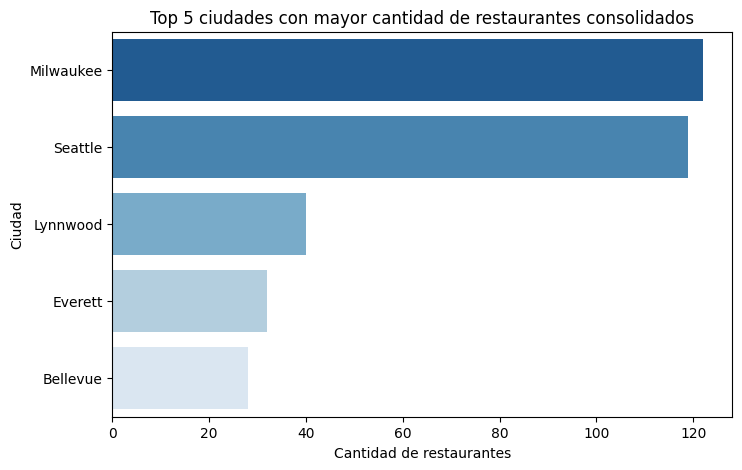

In [44]:
# Grafico: Top 5 ciudades con mas restaurantes

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_ciudades,
    x="cantidad_restaurantes",
    y="ciudad",
    hue="ciudad",
    palette="Blues_r",
    legend=False
)

plt.title("Top 5 ciudades con mayor cantidad de restaurantes consolidados")
plt.xlabel("Cantidad de restaurantes")
plt.ylabel("Ciudad")

plt.show()

📌 Conclusión para el CEO:

Milwaukee y Seattle concentran la mayor cantidad de restaurantes consolidados, por lo que representan mercados prioritarios para analizar una posible expansión.

## Pregunta 2: Análisis de Oportunidad de Precio

¿Cuál es la distribución de restaurantes según su rango de precio?

In [59]:
query_precios = """
SELECT
    price_range,
    COUNT(DISTINCT restaurant_id) AS cantidad_restaurantes
FROM master_food_data
GROUP BY price_range
ORDER BY cantidad_restaurantes DESC;
"""

query_precios

'\nSELECT \n    price_range,\n    COUNT(DISTINCT restaurant_id) AS cantidad_restaurantes\nFROM master_food_data\nGROUP BY price_range\nORDER BY cantidad_restaurantes DESC;\n'

In [46]:


df_precios = pd.read_sql(
    text(query_precios),
    conn
)

df_precios

,price_range,cantidad_restaurantes
0,Económico,450
1,Moderadamente caro,157
2,None,60
3,Caro,4


In [47]:
# Eliminar valores sin categoria de precio para el grafico

df_precios_grafico = df_precios.dropna()

df_precios_grafico

,price_range,cantidad_restaurantes
0,Económico,450
1,Moderadamente caro,157
3,Caro,4


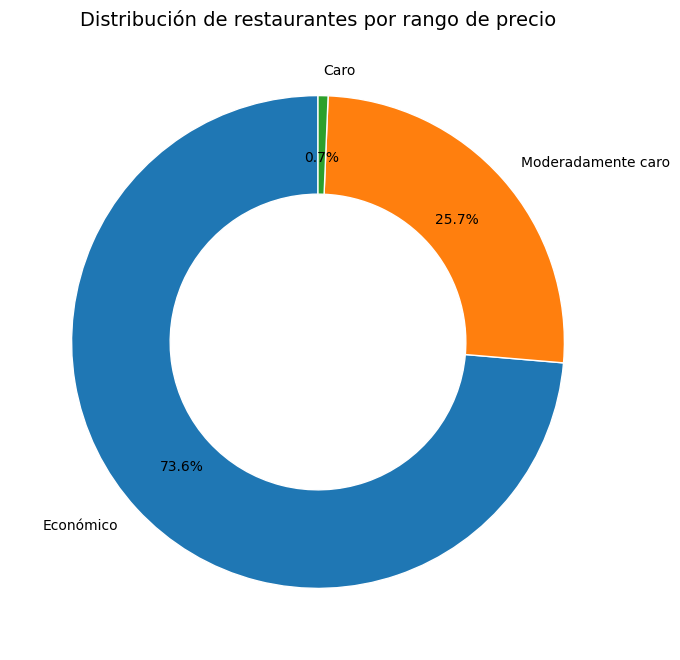

In [49]:
# Grafico Donut - Distribucion de rangos de precio

plt.figure(figsize=(8,8))

plt.pie(
    df_precios_grafico["cantidad_restaurantes"],
    labels=df_precios_grafico["price_range"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.1,
    wedgeprops={"width":0.4, "edgecolor":"white"}
)

plt.title(
    "Distribución de restaurantes por rango de precio",
    fontsize=14
)

plt.show()

📌 Conclusión para el CEO:

El mercado está dominado por restaurantes económicos, mientras que las categorías de mayor precio tienen una participación reducida.

## Pregunta 3: Estrategia de Menú por Ciudad

¿Cuál es el precio promedio de los platos en las ciudades con mayor presencia de restaurantes?

In [50]:
query_menu_ciudad = """
SELECT
    ciudad,
    AVG(price) AS precio_promedio_menu
FROM master_food_data
WHERE ciudad IN ('Milwaukee', 'Seattle', 'Lynnwood')
GROUP BY ciudad
ORDER BY precio_promedio_menu DESC;
"""

query_menu_ciudad

"\nSELECT \n    ciudad,\n    AVG(price) AS precio_promedio_menu\nFROM master_food_data\nWHERE ciudad IN ('Milwaukee', 'Seattle', 'Lynnwood')\nGROUP BY ciudad\nORDER BY precio_promedio_menu DESC;\n"

In [51]:
df_menu_ciudad = pd.read_sql(
    text(query_menu_ciudad),
    conn
)

df_menu_ciudad

,ciudad,precio_promedio_menu
0,Seattle,11.975071
1,Lynnwood,10.818490
2,Milwaukee,9.525836


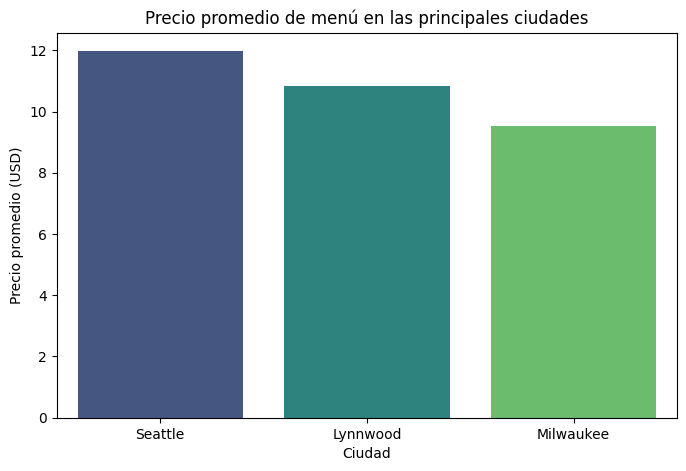

In [62]:
# Grafico - Precio promedio del menu por ciudad

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_menu_ciudad,
    x="ciudad",
    y="precio_promedio_menu",
    hue="ciudad",
    palette="viridis",
    legend=False
)

plt.title("Precio promedio de menú en las principales ciudades")
plt.xlabel("Ciudad")
plt.ylabel("Precio promedio (USD)")

plt.show()

📌 Conclusión para el CEO:

Seattle presenta el mayor precio promedio de menú, lo que indica una oportunidad para estrategias orientadas a consumidores con mayor capacidad de gasto.

## Pregunta 4: Restaurantes mejor evaluados

¿Cuáles son los restaurantes con mejor puntuación y mayor cantidad de reseñas?

In [60]:
query_mejores_restaurantes = """
SELECT
    restaurant_name,
    score,
    ratings,
    ciudad
FROM master_food_data
WHERE score IS NOT NULL
AND ratings IS NOT NULL
GROUP BY restaurant_id
ORDER BY score DESC, ratings DESC
LIMIT 10;
"""

query_mejores_restaurantes

'\nSELECT\n    restaurant_name,\n    score,\n    ratings,\n    ciudad\nFROM master_food_data\nWHERE score IS NOT NULL\nAND ratings IS NOT NULL\nGROUP BY restaurant_id\nORDER BY score DESC, ratings DESC\nLIMIT 10;\n'

In [61]:
df_mejores_restaurantes = pd.read_sql(
    text(query_mejores_restaurantes),
    conn
)

df_mejores_restaurantes

,restaurant_name,score,ratings,ciudad
0,Teriyaki Plus,5.0,110.0,Kirkland
1,Colectivo Prospect,5.0,103.0,Milwaukee
2,Starbucks (84th &amp; Bluemound),4.9,200.0,Wauwatosa
3,Starbucks (Rte 12 &amp; Hartigan - Volo),4.9,200.0,Volo
4,Midnight Cookie Co. (Seattle),4.9,200.0,Seattle
5,Hello Robin,4.9,200.0,Seattle
6,Chops,4.9,200.0,Lynnwood
7,Valhalla Sandwiches,4.9,200.0,Seattle
8,Chop Express,4.9,200.0,Everett
9,Evergreens (Fremont),4.9,200.0,Seattle


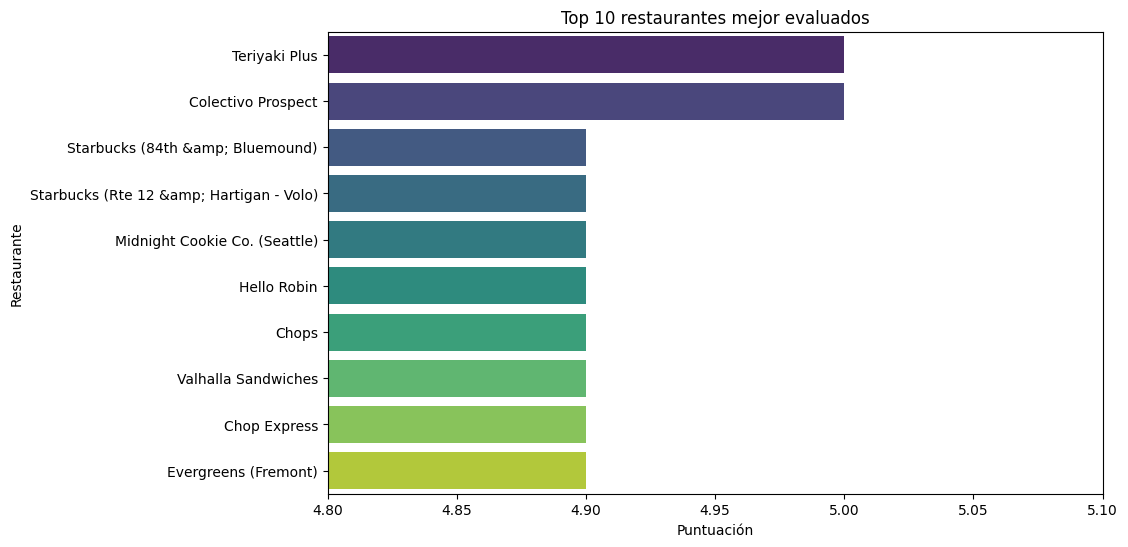

In [57]:
# Grafico - Restaurantes mejor evaluados

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_mejores_restaurantes,
    x="score",
    y="restaurant_name",
    hue="restaurant_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 restaurantes mejor evaluados")
plt.xlabel("Puntuación")
plt.ylabel("Restaurante")

plt.xlim(4.8, 5.1)

plt.show()

📌 Conclusión para el CEO:

Los restaurantes con mejores puntuaciones mantienen calificaciones cercanas a 5 estrellas, destacando referentes de calidad que pueden servir como modelos de buenas prácticas.



